## Toronto 311 Service Request Analysis: Identifying Service Demand Patterns and Operational Priorities in 2025
### Business problem
The City of Toronto receives hundreds of thousands of 311 service requests every year. Understanding where requests are coming from, when demand is highest, and which issues residents report most often can help the City prioritize work and allocate resources more effectively.

### Project objective
This project analyzes the 2025 Toronto 311 Service Request dataset to identify patterns in resident-reported issues across the city. The analysis focuses on three questions:

1. **Which services generate the most requests?**

Identify the municipal services with the highest request volumes and the city divisions responsible for responding to them.

2. **When is demand highest?**

Examine monthly, weekly, and hourly trends to understand how service demand changes throughout the year.

3. **Where is demand concentrated?**

Compare request volumes across Toronto wards to identify areas with the greatest demand for municipal services.

The findings highlight service demand patterns and support data-informed decisions about resource planning and service delivery.

### Dataset Overview and Source

This analysis uses the 2025 Toronto 311 Service Request dataset, which contains service requests submitted by residents through the city's 311 system.

Each record represents a single service request and includes information about the request type, responsible city division, status, location, and when the request was created.

The dataset is publicly available through Toronto's Open Data Portal.

### Data Quality & Cleaning

Before beginning the exploratory analysis, I reviewed the dataset for formatting issues, missing values, inconsistent categories, duplicate records, and incorrect data types. The cleaning process focused on preparing the data for reliable analysis while preserving as much of the original information as possible.

The main cleaning steps included:

* Standardizing column names and categorical values
* Converting the creation date to a datetime format
* Reviewing and handling missing or inconsistent values
* Separating ward names and ward numbers
* Checking critical fields for missing data
* Identifying and removing duplicate records

**1. Initial Data Inspection**

I first reviewed the dataset's structure, dimensions, data types, missing values, and sample records to identify potential data quality issues before making any changes.

**2. Column Names and Date Formatting**

Column names were converted to `snake_case` for consistency and easier use in Python. The `creation_date` field was also converted from text to a datetime format so it could be used for time-based analysis.

**3. Categorical Data Cleaning**

Categorical fields were checked for inconsistent spacing and capitalization. Leading and trailing whitespace was removed, and selected columns were standardized to consistent title casing.

**4. Handling Inconsistent and Missing Values**

Known inconsistent values were reviewed and corrected where appropriate. Missing values in key fields were also checked separately to make sure records used in the analysis contained the information required for the main business questions.

**5. Ward Data Cleaning**

The original ward field contains both the ward name and ward number. These were separated into `ward_name` and `ward_number` to make geographic analysis easier while keeping the original ward field available for reference.

**6. Duplicate Records**

Exact duplicate rows were identified and removed to prevent the same service request record from being counted more than once.

**7. Final Data Quality Checks**

After cleaning, the dataset was checked again for duplicates, missing values in critical fields, invalid dates, and the number of unique wards before moving into the exploratory analysis.

In [37]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default visualization style
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [38]:
# Load the Toronto 311 Service Request dataset
# The CSV contains inconsistent row lengths, therefore:
# - latin1 encoding is used to handle special characters
# - the Python engine allows more flexible parsing
# - custom column names ensure a consistent 10-column structure

column_names = [
    "Creation Date",
    "Status",
    "Postal Code 3",
    "Street 1",
    "Street 2",
    "Ward",
    "Service Request Type",
    "Division",
    "Section",
    "Subsection"
]

df = pd.read_csv(
    "SR2025.csv",
    encoding="latin1",
    engine="python",
    header=None,
    names=column_names
)

# Keep a copy of the original dataset before cleaning
df_raw = df.copy()

In [39]:
# Preview the dataset
df.head()

,Creation Date,Status,Postal Code 3,Street 1,Street 2,Ward,Service Request Type,Division,Section,Subsection
0,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,None
1,2025-01-01 00:01:05.0000000,Completed,M8Y,NaN,NaN,Etobicoke-Lakeshore (03),Injured - Domestic,Municipal Licensing & Standards,Toronto Animal Services,None
2,2025-01-01 00:02:16.0000000,Completed,M5V,NaN,NaN,Spadina-Fort York (10),Amplified Sound or Instrument Sound,Municipal Licensing & Standards,Bylaw Enforcement,None
3,2025-01-01 00:14:46.0000000,Cancelled,M1V,NaN,NaN,Scarborough North (23),Zoning Regulations Violations,Municipal Licensing & Standards,Investigation Services,None
4,2025-01-01 00:16:28.0000000,Completed,M1V,NaN,NaN,Scarborough North (23),Illegal Off-Street Parking,Transportation Services,Right of Way (ROW),None


In [40]:
# Check dataset dimensions
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 500,270
Columns: 10


In [41]:
# Review column data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500270 entries, 0 to 500269
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Creation Date         500270 non-null  object
 1   Status                500270 non-null  object
 2   Postal Code 3         500270 non-null  object
 3   Street 1              78458 non-null   object
 4   Street 2              77834 non-null   object
 5   Ward                  500270 non-null  object
 6   Service Request Type  500270 non-null  object
 7   Division              500270 non-null  object
 8   Section               500270 non-null  object
 9   Subsection            36189 non-null   object
dtypes: object(10)
memory usage: 38.2+ MB


In [42]:
# Check missing values
df.isna().sum()

Creation Date                0
Status                       0
Postal Code 3                0
Street 1                421812
Street 2                422436
Ward                         0
Service Request Type         0
Division                     0
Section                      0
Subsection              464081
dtype: int64

In [43]:
# Inspect the most common service request types
df["Service Request Type"].value_counts().head(10)

Service Request Type
Residential Bin Lid Damaged                      24448
Property Standards and Maintenance Violations    17079
Pick up Dead Wildlife                            15513
Injured - Wildlife                               15192
General Pruning                                  12873
Road Pothole / Road Damage                       11304
Residential Bin Body or Handle Damaged           11238
Sidewalk Snow Clearing Required                  10241
Res / Garbage / Not Picked Up                     9159
Residential Furniture / Not Picked Up             8634
Name: count, dtype: int64

In [44]:
# Convert column names to snake_case for easier analysis
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# Remove the first row, which contains the original CSV header
df = df.drop(index=0).reset_index(drop=True)

# Convert creation_date to datetime
df["creation_date"] = pd.to_datetime(
    df["creation_date"],
    errors="coerce"
)

df.head()

,creation_date,status,postal_code_3,street_1,street_2,ward,service_request_type,division,section,subsection
0,2025-01-01 00:01:05,Completed,M8Y,NaN,NaN,Etobicoke-Lakeshore (03),Injured - Domestic,Municipal Licensing & Standards,Toronto Animal Services,None
1,2025-01-01 00:02:16,Completed,M5V,NaN,NaN,Spadina-Fort York (10),Amplified Sound or Instrument Sound,Municipal Licensing & Standards,Bylaw Enforcement,None
2,2025-01-01 00:14:46,Cancelled,M1V,NaN,NaN,Scarborough North (23),Zoning Regulations Violations,Municipal Licensing & Standards,Investigation Services,None
3,2025-01-01 00:16:28,Completed,M1V,NaN,NaN,Scarborough North (23),Illegal Off-Street Parking,Transportation Services,Right of Way (ROW),None
4,2025-01-01 00:25:00,Completed,M9R,NaN,NaN,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement,None


In [45]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Remove leading and trailing whitespace
df[cat_cols] = df[cat_cols].apply(lambda col: col.str.strip())

In [46]:
# Standardize capitalization in selected categorical fields
title_case_cols = [
    "status",
    "service_request_type",
    "ward",
    "division",
    "section",
    "subsection"
]

for col in title_case_cols:
    df[col] = df[col].str.title()

In [47]:
# Standardize known inconsistent values
df["status"] = df["status"].replace({
    "In Progress": "In-Progress"
})

df["ward"] = df["ward"].replace({
    "S": np.nan,
    "Nan": np.nan
})

df["subsection"] = df["subsection"].replace({
    "Nan": np.nan
})

In [48]:
# Separate ward name and ward number
df["ward_number"] = df["ward"].str.extract(r"\((\d+)\)")

df["ward_name"] = (
    df["ward"]
      .str.replace(r"\s*\(\d+\)", "", regex=True)
      .str.strip()
)

In [49]:
df["ward_number"] = df["ward_number"].astype("Int64")

In [50]:
df[["ward", "ward_name", "ward_number"]].head()

,ward,ward_name,ward_number
0,Etobicoke-Lakeshore (03),Etobicoke-Lakeshore,3
1,Spadina-Fort York (10),Spadina-Fort York,10
2,Scarborough North (23),Scarborough North,23
3,Scarborough North (23),Scarborough North,23
4,Etobicoke Centre (02),Etobicoke Centre,2


In [51]:
# Review common values in key categorical columns
for col in ["status", "division", "service_request_type", "ward"]:
    print(f"\n--- {col.upper()} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- STATUS ---
status
Completed      392653
Cancelled       51669
In-Progress     22047
New             16816
Closed          10167
Unknown          6917
Name: count, dtype: int64

--- DIVISION ---
division
Solid Waste Management Services    170443
Transportation Services            130056
Municipal Licensing & Standards    117630
Toronto Water                       36839
Environment                         36174
311                                  7690
Parks And Recreation                 1437
Name: count, dtype: int64

--- SERVICE_REQUEST_TYPE ---
service_request_type
Residential Bin Lid Damaged                        24448
Property Standards And Maintenance Violations      17079
Pick Up Dead Wildlife                              15513
Injured - Wildlife                                 15192
General Pruning                                    12873
Road Pothole / Road Damage                         11304
Residential Bin Body Or Handle Damaged             11238
Sidewalk Snow Clearing

In [52]:
# Check missing values in fields required for the main analysis
critical_fields = [
    "creation_date",
    "status",
    "service_request_type",
    "division"
]

df[critical_fields].isna().sum()

creation_date           0
status                  0
service_request_type    0
division                0
dtype: int64

In [53]:
# Check for missing values stored as text
fake_missing = ["", " ", "NaN", "Nan", "nan", "NULL", "None"]

for col in critical_fields:
    count = df[col].isin(fake_missing).sum()
    print(f"{col}: {count} potential text-based missing values")

creation_date: 0 potential text-based missing values
status: 0 potential text-based missing values
service_request_type: 0 potential text-based missing values
division: 0 potential text-based missing values


In [54]:
df["creation_date"].isna().sum()

np.int64(0)

In [55]:
# Count exact duplicate rows
df.duplicated().sum()

np.int64(689)

In [56]:
# Inspect duplicate rows
df[df.duplicated()]

,creation_date,status,postal_code_3,street_1,street_2,ward,service_request_type,division,section,subsection,ward_number,ward_name
9247,2025-01-09 10:44:59,Completed,M4B,NaN,NaN,Scarborough Southwest (20),Watermain-Possible Break,Toronto Water,District Ops,None,20,Scarborough Southwest
10526,2025-01-10 09:25:19,Cancelled,M8Z,NaN,NaN,Etobicoke-Lakeshore (03),Injured - Wildlife,Municipal Licensing & Standards,Toronto Animal Services,None,3,Etobicoke-Lakeshore
11348,2025-01-10 17:08:16,Completed,M4C,NaN,NaN,Beaches-East York (19),Res / Recycle / Not Picked Up,Solid Waste Management Services,Collections,None,19,Beaches-East York
33133,2025-02-01 13:32:04,Cancelled,Intersection,Dowling Ave,King St W,Parkdale-High Park (04),Pick Up Dead Wildlife,Municipal Licensing & Standards,Toronto Animal Services,None,4,Parkdale-High Park
33809,2025-02-02 18:32:15,Cancelled,M4N,NaN,NaN,Don Valley West (15),Investigate - Dog Frequently At Large,Municipal Licensing & Standards,Toronto Animal Services,None,15,Don Valley West
...,...,...,...,...,...,...,...,...,...,...,...,...
499252,2025-12-31 09:37:28,Cancelled,M1E,NaN,NaN,Scarborough-Guildwood (24),Pick Up Dead Wildlife,Municipal Licensing & Standards,Toronto Animal Services,None,24,Scarborough-Guildwood
499253,2025-12-31 09:37:28,Cancelled,M1E,NaN,NaN,Scarborough-Guildwood (24),Pick Up Dead Wildlife,Municipal Licensing & Standards,Toronto Animal Services,None,24,Scarborough-Guildwood
499359,2025-12-31 10:19:31,Cancelled,Intersection,Mimico Waterfront Park Trl,Norris Cres,Etobicoke-Lakeshore (03),Injured - Wildlife,Municipal Licensing & Standards,Toronto Animal Services,None,3,Etobicoke-Lakeshore
499410,2025-12-31 10:50:02,Cancelled,M1X,NaN,NaN,Scarborough North (23),Pick Up Dead Wildlife,Municipal Licensing & Standards,Toronto Animal Services,None,23,Scarborough North


In [57]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

In [58]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [59]:
# Final data quality checks

print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Invalid creation dates:", df["creation_date"].isna().sum())
print("Unique wards:", df["ward_number"].nunique())

print("\nMissing values in critical fields:")
print(df[critical_fields].isna().sum())

Dataset shape: (499580, 12)
Duplicate rows: 0
Invalid creation dates: 0
Unique wards: 25

Missing values in critical fields:
creation_date           0
status                  0
service_request_type    0
division                0
dtype: int64


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499580 entries, 0 to 499579
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   creation_date         499580 non-null  datetime64[ns]
 1   status                499580 non-null  object        
 2   postal_code_3         499580 non-null  object        
 3   street_1              78355 non-null   object        
 4   street_2              77731 non-null   object        
 5   ward                  499580 non-null  object        
 6   service_request_type  499580 non-null  object        
 7   division              499580 non-null  object        
 8   section               499580 non-null  object        
 9   subsection            36189 non-null   object        
 10  ward_number           499573 non-null  Int64         
 11  ward_name             499580 non-null  object        
dtypes: Int64(1), datetime64[ns](1), object(10)
memory usage: 4

In [61]:
df.head()

,creation_date,status,postal_code_3,street_1,street_2,ward,service_request_type,division,section,subsection,ward_number,ward_name
0,2025-01-01 00:01:05,Completed,M8Y,NaN,NaN,Etobicoke-Lakeshore (03),Injured - Domestic,Municipal Licensing & Standards,Toronto Animal Services,None,3,Etobicoke-Lakeshore
1,2025-01-01 00:02:16,Completed,M5V,NaN,NaN,Spadina-Fort York (10),Amplified Sound Or Instrument Sound,Municipal Licensing & Standards,Bylaw Enforcement,None,10,Spadina-Fort York
2,2025-01-01 00:14:46,Cancelled,M1V,NaN,NaN,Scarborough North (23),Zoning Regulations Violations,Municipal Licensing & Standards,Investigation Services,None,23,Scarborough North
3,2025-01-01 00:16:28,Completed,M1V,NaN,NaN,Scarborough North (23),Illegal Off-Street Parking,Transportation Services,Right Of Way (Row),None,23,Scarborough North
4,2025-01-01 00:25:00,Completed,M9R,NaN,NaN,Etobicoke Centre (02),Fireworks,Municipal Licensing & Standards,Parks Enforcement,None,2,Etobicoke Centre


### Exploratory Data Analysis

With the dataset cleaned and prepared, the exploratory analysis focuses on understanding the volume, timing, and geographic distribution of Toronto 311 service requests.

The analysis is organized around the three main project questions:

1. Which services generate the most requests?
2. When is demand highest?
3. Where is demand concentrated?

Additional analysis is used to investigate seasonal patterns and selected service issues in more detail.

### 1. Overall Service Request Patterns

I first examined the overall distribution of service requests to understand which issues residents report most frequently, which city divisions receive the most requests, and the status of those requests.

In [62]:
# Count requests and calculate percentage by status
status_summary = pd.DataFrame({
    "request_count": df["status"].value_counts(),
    "percentage": (
        df["status"].value_counts(normalize=True) * 100
    ).round(1)
})

status_summary

,request_count,percentage
status,,
Completed,392488,78.6
Cancelled,51151,10.2
In-Progress,22047,4.4
New,16816,3.4
Closed,10161,2.0
Unknown,6917,1.4


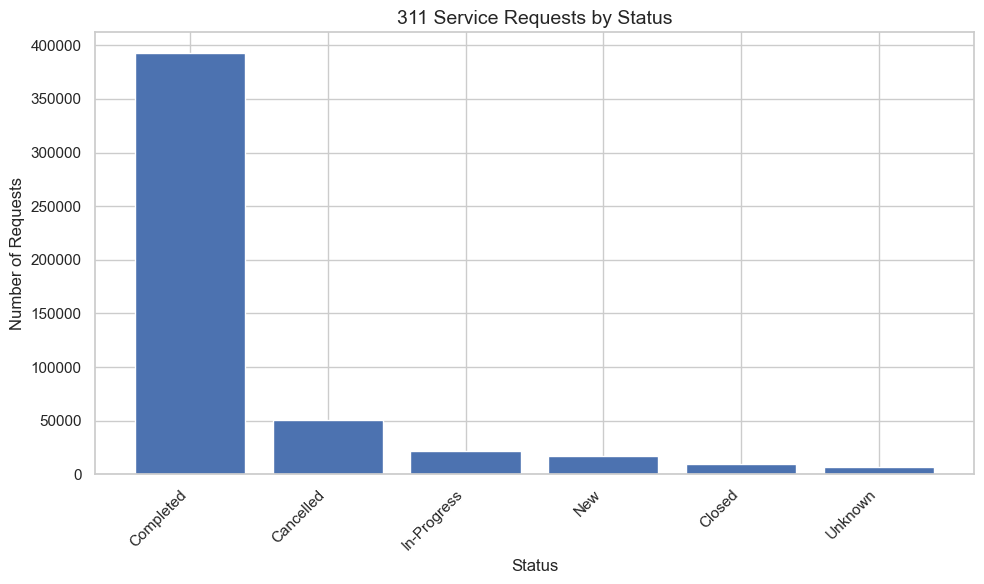

In [63]:
# Plot service request status distribution
status_counts = df["status"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(status_counts.index, status_counts.values)

plt.title("311 Service Requests by Status")
plt.xlabel("Status")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Key insight:** Approximately 78.6% of service requests were marked as Completed, making it by far the most common status. Cancelled requests accounted for about 10.2% of the dataset, while the remaining statuses each represented a relatively small share of requests.

The proportion of cancelled requests is worth examining further, since understanding why requests are cancelled could help identify duplicate submissions, requests that fall outside 311's scope, or other process issues. The dataset alone, however, does not explain the reason for cancellation.


#### Most Common Service Request Types

In [64]:
# Count unique service request types
print("Unique service request types:", df["service_request_type"].nunique())

# Identify the 10 most common request types
top_requests = (
    df["service_request_type"]
    .value_counts()
    .head(10)
)

top_requests

Unique service request types: 538


service_request_type
Residential Bin Lid Damaged                      24448
Property Standards And Maintenance Violations    17051
Pick Up Dead Wildlife                            15357
Injured - Wildlife                               14968
General Pruning                                  12873
Road Pothole / Road Damage                       11304
Residential Bin Body Or Handle Damaged           11238
Sidewalk Snow Clearing Required                  10240
Res / Garbage / Not Picked Up                     9157
Residential Furniture / Not Picked Up             8634
Name: count, dtype: int64

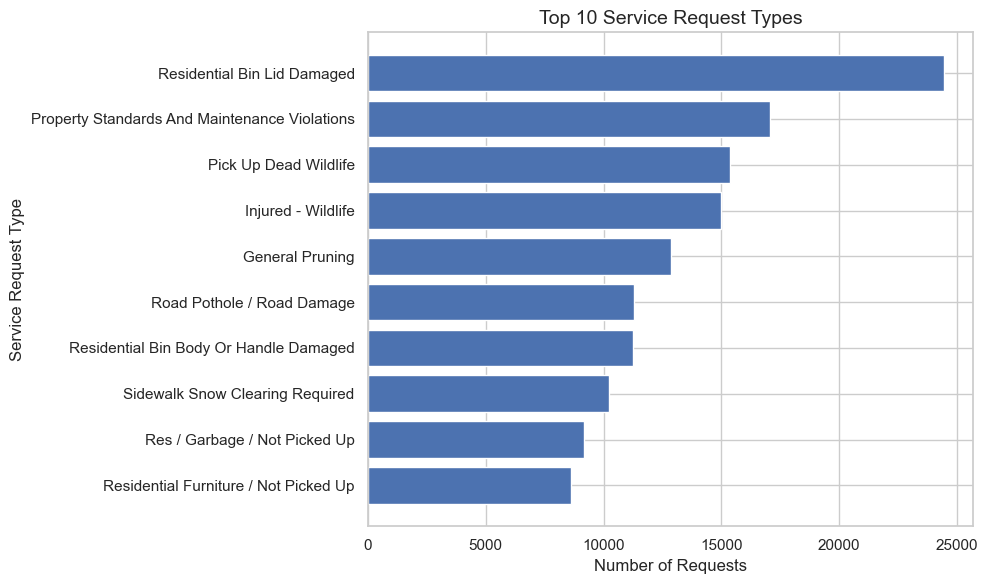

In [65]:
# Plot the 10 most common service request types
plt.figure(figsize=(10, 6))
plt.barh(top_requests.index, top_requests.values)

plt.title("Top 10 Service Request Types")
plt.xlabel("Number of Requests")
plt.ylabel("Service Request Type")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Key insight:** Residential Bin Lid Damaged was the most frequently reported issue, with 24,448 requests. Property Standards and Maintenance Violations followed with 17,051 requests.

Wildlife-related issues were also prominent. Pick up Dead Wildlife and Injured - Wildlife both appeared among the five most common request types. Road Pothole / Road Damage ranked sixth overall with 11,304 requests.

The range of high-volume categories suggests that 311 demand is spread across several types of municipal services rather than being driven by a single issue.

#### Requests by City Division

In [66]:
# Count requests handled by each city division
division_requests = df["division"].value_counts()

division_requests

division
Solid Waste Management Services    170437
Transportation Services            130051
Municipal Licensing & Standards    116955
Toronto Water                       36836
Environment                         36174
311                                  7690
Parks And Recreation                 1437
Name: count, dtype: int64

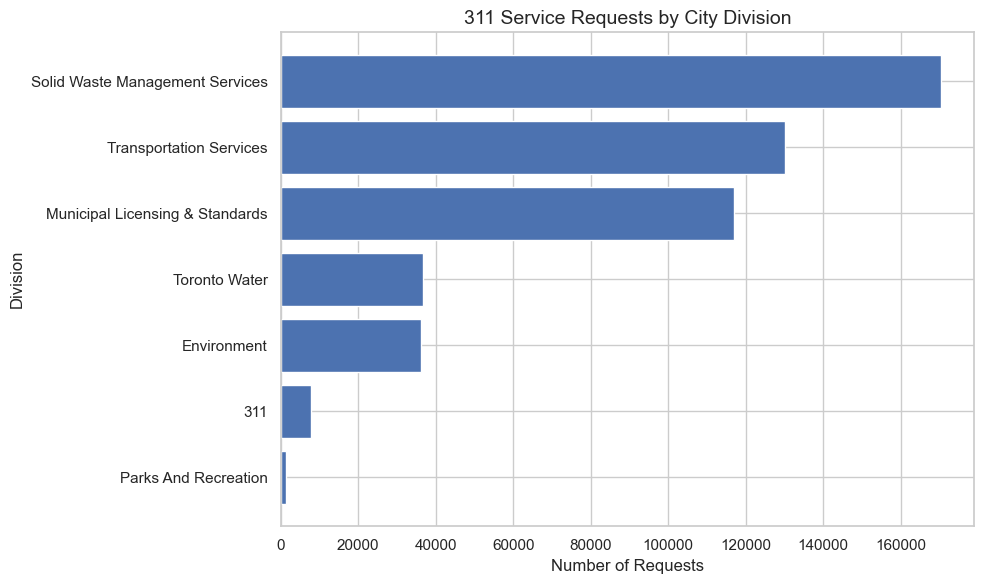

In [67]:
# Plot requests by city division
plt.figure(figsize=(10, 6))
plt.barh(division_requests.index, division_requests.values)

plt.title("311 Service Requests by City Division")
plt.xlabel("Number of Requests")
plt.ylabel("Division")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Key insight:** Solid Waste Management Services handled the largest number of requests, with 170,437 records, followed by Transportation Services with 130,051 and Municipal Licensing & Standards with 116,955

Together, these divisions account for a large share of 311 activity and represent areas where changes in service demand could have a substantial impact on overall request volumes.

### 2. When Is 311 Demand Highest?

Service request volume was analyzed by month, day of the week, and hour of the day to identify periods when demand is highest and determine whether consistent time-based patterns appear in the data.

#### Requests by Month

In [69]:
# Create a month column
df['month'] = df['creation_date'].dt.month

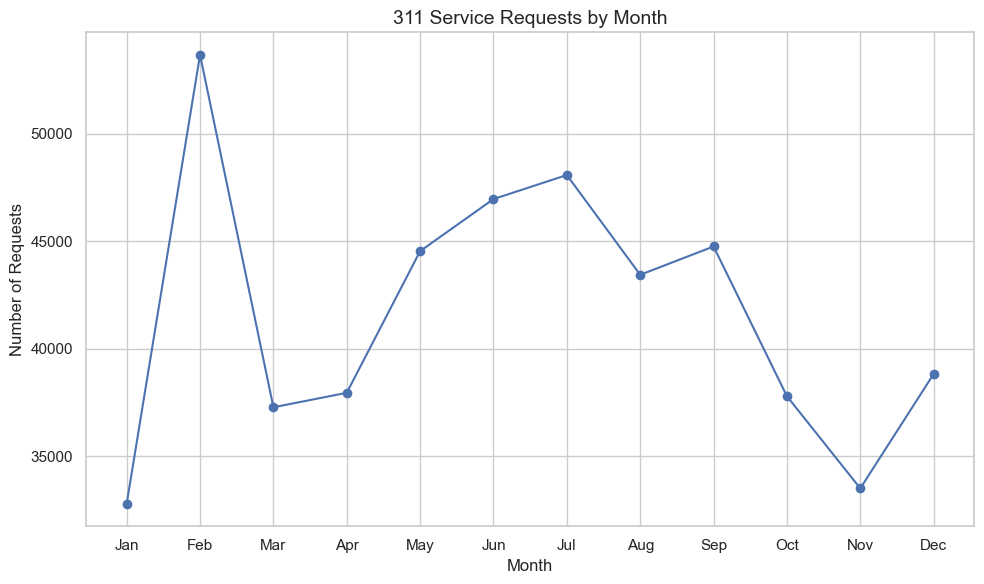

In [71]:
# Count requests by month
monthly_requests = (
    df["month"]
    .value_counts()
    .sort_index()
)

# Plot monthly service request volume
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_requests.index,
    monthly_requests.values,
    marker="o"
)

plt.title("311 Service Requests by Month")
plt.xlabel("Month")
plt.ylabel("Number of Requests")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.tight_layout()
plt.show()

**Key insight:** Service request volume varies substantially throughout the year. February recorded the highest overall volume, followed by a sharp decline in March. Requests then increased through the spring and early summer, reaching another high point in July before generally declining toward the end of the year.

The large February spike suggests that seasonal conditions may have a strong influence on 311 demand. To investigate this further, the most common request types in February are compared with those in July later in the analysis.

#### Request by Day of Week

In [75]:
df['day_name'] = df['creation_date'].dt.day_name()

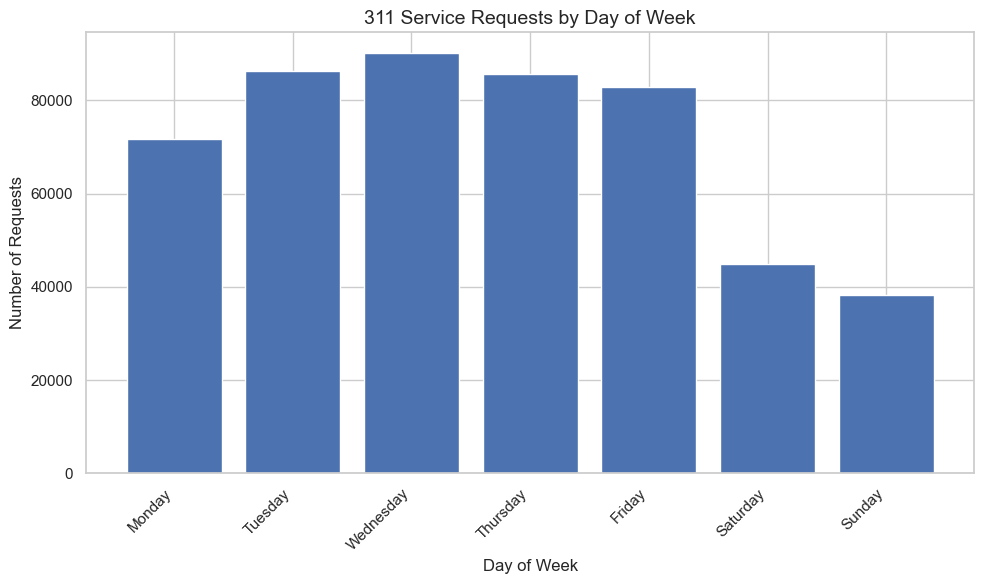

In [76]:
# Order days from Monday to Sunday
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Count requests by day of week
daily_requests = (
    df["day_name"]
    .value_counts()
    .reindex(day_order)
)

# Plot requests by day of week
plt.figure(figsize=(10, 6))
plt.bar(daily_requests.index, daily_requests.values)

plt.title("311 Service Requests by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Key insight:** Request volume is highest during the middle of the workweek, with Wednesday recording the most requests. Tuesday through Friday show relatively similar levels of demand, while request volume drops considerably on Saturday and Sunday.

This pattern suggests that the timing of 311 reports may be influenced not only by when issues occur, but also by when residents are more likely to report them.

#### Requests by Hour

In [79]:
df['hour'] = df['creation_date'].dt.hour

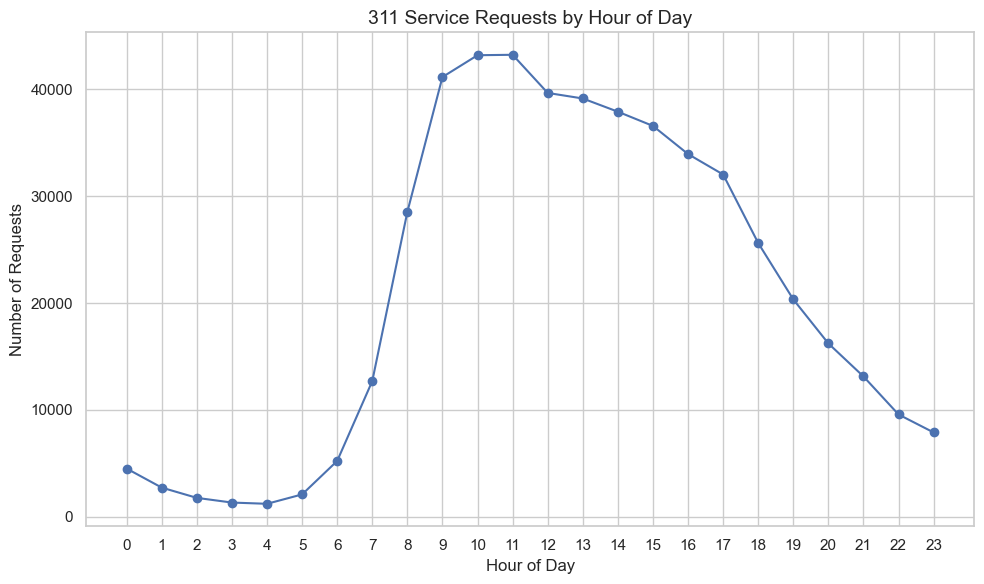

In [80]:
# Count requests by hour
hourly_requests = (
    df["hour"]
    .value_counts()
    .sort_index()
)

# Plot requests by hour of day
plt.figure(figsize=(10, 6))
plt.plot(
    hourly_requests.index,
    hourly_requests.values,
    marker="o"
)

plt.title("311 Service Requests by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")

plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Key insight:** Service request activity is lowest during the early morning hours and increases sharply after approximately 7:00 AM. Request volume reaches its highest level around 10:00–11:00 AM before gradually declining through the afternoon and evening.

This indicates a clear daytime reporting pattern, with the majority of 311 activity occurring during typical waking and working hours.

#### Investigating the February Spike

#### Seasonal Differences: February vs. July
February recorded the highest overall request volume, while July represented another period of relatively high demand during a very different season. Comparing the most common request types in these two months helps determine whether the underlying drivers of 311 demand change throughout the year.

In [82]:
# Identify the most common service requests in February
february_requests = (
    df[df["month"] == 2]["service_request_type"]
    .value_counts()
    .head(10)
)

february_requests

service_request_type
Sidewalk Snow Clearing Required                                           8721
Road Plowing Request                                                      4987
Driveway Blocked By Plowed Snowbank                                       3811
Publication Request - Solid Waste                                         1405
Snow At Intersections - Impeded Mobility                                  1248
Residential Bin Lid Damaged                                               1233
Road Pothole / Road Damage                                                1154
Icy Sidewalk Needs Salting                                                1108
Illegal Snow Dumping & Failure To Clear Snow Or Ice On Public Sidewalk    1098
Property Standards And Maintenance Violations                             1091
Name: count, dtype: int64

In [83]:
# Identify the most common service requests in July
july_requests = (
    df[df["month"] == 7]["service_request_type"]
    .value_counts()
    .head(10)
)

july_requests

service_request_type
General Pruning                                         2512
Residential Bin Lid Damaged                             2291
Pick Up Dead Wildlife                                   1997
Property Standards And Maintenance Violations           1813
Injured - Wildlife                                      1493
Tree Emergency Clean-Up                                 1132
Residential Bin Body Or Handle Damaged                  1118
Long Grass And Prohibited Plants On Private Property     960
Residential Furniture / Not Picked Up                    951
Res / Garbage / Not Picked Up                            832
Name: count, dtype: int64

**Key insight:** The types of requests driving demand differ considerably between winter and summer.

In February, the most common request was Sidewalk Snow Clearing Required, with 8,721 requests. Road Plowing Requests and Driveway Blocked by Plowed Snowbank were also among the leading categories, showing that winter weather was a major contributor to February's unusually high request volume.

July shows a very different pattern. General Pruning was the most common request, followed by Residential Bin Lid Damaged, Pick up Dead Wildlife, and Property Standards and Maintenance Violations.

These differences show that overall 311 demand is strongly influenced by season, but the services experiencing the highest demand change throughout the year.

#### Weekday vs. Weekend Requests
Because overall request volume falls considerably on weekends, I compared the most common request categories on weekdays and weekends to determine whether the types of issues being reported also change.

In [84]:
# Separate weekday and weekend requests
weekday_data = df[df["day_name"].isin([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"
])]

weekend_data = df[df["day_name"].isin([
    "Saturday", "Sunday"
])]

In [85]:
# Most common weekday requests
weekday_requests = (
    weekday_data["service_request_type"]
    .value_counts()
    .head(10)
)

weekday_requests

service_request_type
Residential Bin Lid Damaged                      21750
Property Standards And Maintenance Violations    14390
General Pruning                                  11383
Pick Up Dead Wildlife                            11252
Injured - Wildlife                               10727
Residential Bin Body Or Handle Damaged           10064
Road Pothole / Road Damage                        9048
Sidewalk Snow Clearing Required                   8651
Res / Garbage / Not Picked Up                     8573
Res / Recycle / Not Picked Up                     7800
Name: count, dtype: int64

In [86]:
# Most common weekend requests
weekend_requests = (
    weekend_data["service_request_type"]
    .value_counts()
    .head(10)
)

weekend_requests

service_request_type
Injured - Wildlife                               4241
Pick Up Dead Wildlife                            4105
Amplified Sound Or Instrument Sound              2811
Residential Bin Lid Damaged                      2698
Property Standards And Maintenance Violations    2661
Road Pothole / Road Damage                       2256
Amplified Or Musical Instrument Noise            1711
Traffic Signal Repair                            1633
Sidewalk Snow Clearing Required                  1589
Construction Noise                               1532
Name: count, dtype: int64

**Key insight:** Weekday requests are dominated by municipal operations such as waste collection, property standards, pruning, and road maintenance. Weekend requests show a somewhat different pattern, with wildlife and noise-related complaints becoming more prominent.

For example, Injured - Wildlife and Pick up Dead Wildlife were the two most common weekend categories, while multiple noise-related request types also appeared in the weekend top 10.

This suggests that both the volume and composition of 311 demand change between weekdays and weekends.

#### Peak-Hour Analysis

**What Drives Peak-Hour Demand?**
Since overall request volume peaks around 10:00–11:00 AM, I examined the most frequently reported issues during those hours to understand which services contribute most to the daily peak.

In [87]:
# Filter requests submitted during the 10–11 AM peak
peak_hour_data = df[df["hour"].isin([10, 11])]

# Identify the most common requests during peak hours
peak_hour_requests = (
    peak_hour_data["service_request_type"]
    .value_counts()
    .head(10)
)

peak_hour_requests

service_request_type
Residential Bin Lid Damaged                        4830
Property Standards And Maintenance Violations      3217
General Pruning                                    2982
Pick Up Dead Wildlife                              2612
Injured - Wildlife                                 2413
Residential Bin Body Or Handle Damaged             2282
Sidewalk Snow Clearing Required                    1740
Road Pothole / Road Damage                         1707
Tree Emergency Clean-Up                            1359
Clean Up Illegal Dumping On City Road Allowance    1353
Name: count, dtype: int64

**Key insight:** The busiest hours are driven by many of the same categories that dominate overall request volume. Residential Bin Lid Damaged was the most common request during the 10:00–11:00 AM peak, followed by Property Standards and Maintenance Violations and General Pruning.

This suggests that the mid-morning peak is not caused by one unusual category, but instead reflects higher reporting activity across several common municipal service issues.

### 3. Road Pothole and Road Damage Analysis

Road Pothole / Road Damage was one of the most common service request types in the dataset. I examined when these requests occur and where they are concentrated to better understand how road maintenance demand changes throughout the year and across Toronto.

In [88]:
# Filter pothole and road damage requests
pothole_data = df[
    df["service_request_type"] == "Road Pothole / Road Damage"
]

# Count pothole requests by month
monthly_potholes = (
    pothole_data["month"]
    .value_counts()
    .sort_index()
)

monthly_potholes

month
1      459
2     1154
3     3155
4     1293
5     1128
6      914
7      726
8      552
9      473
10     464
11     403
12     583
Name: count, dtype: int64

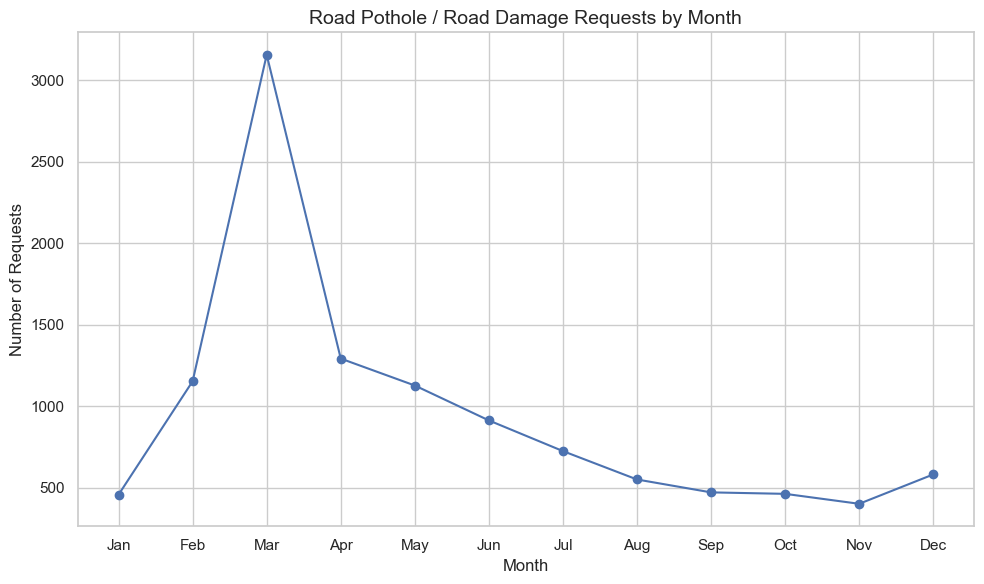

In [89]:
# Plot pothole and road damage requests by month
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_potholes.index,
    monthly_potholes.values,
    marker="o"
)

plt.title("Road Pothole / Road Damage Requests by Month")
plt.xlabel("Month")
plt.ylabel("Number of Requests")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.tight_layout()
plt.show()

**Key insight:** Road pothole and road damage requests show a strong seasonal pattern. Requests increased from 459 in January to 1,154 in February before reaching a sharp peak of 3,155 in March.

After March, request volume declined substantially and generally continued falling through the remainder of the year.

The timing of the spike is consistent with road damage becoming more visible after winter conditions. While the 311 data shows when residents reported road damage, additional weather or road-condition data would be needed to determine the specific causes of the increase.

### 4. Where Is Service Demand Concentrated?

To understand how service demand varies across Toronto, I compared total 311 request volumes across the city's wards. I then examined the most common issues in the highest-volume ward and compared pothole requests across wards.

#### Requests by Ward

In [90]:
# Count requests by ward
ward_requests = df["ward_name"].value_counts()

ward_requests

ward_name
Toronto-Danforth            30448
University-Rosedale         27081
Davenport                   27073
Beaches-East York           26989
Etobicoke-Lakeshore         25813
Parkdale-High Park          25473
Eglinton-Lawrence           24200
Scarborough Southwest       22272
Toronto-St. Paul'S          21718
Spadina-Fort York           21219
Etobicoke Centre            21216
York South-Weston           20739
Don Valley West             19614
Scarborough-Rouge Park      19380
York Centre                 18829
Scarborough Centre          18758
Toronto Centre              18694
Willowdale                  15502
Scarborough-Guildwood       15414
Etobicoke North             15380
Don Valley North            13723
Humber River-Black Creek    13482
Scarborough-Agincourt       12662
Scarborough North           12297
Don Valley East             11597
Unknown                         7
Name: count, dtype: int64

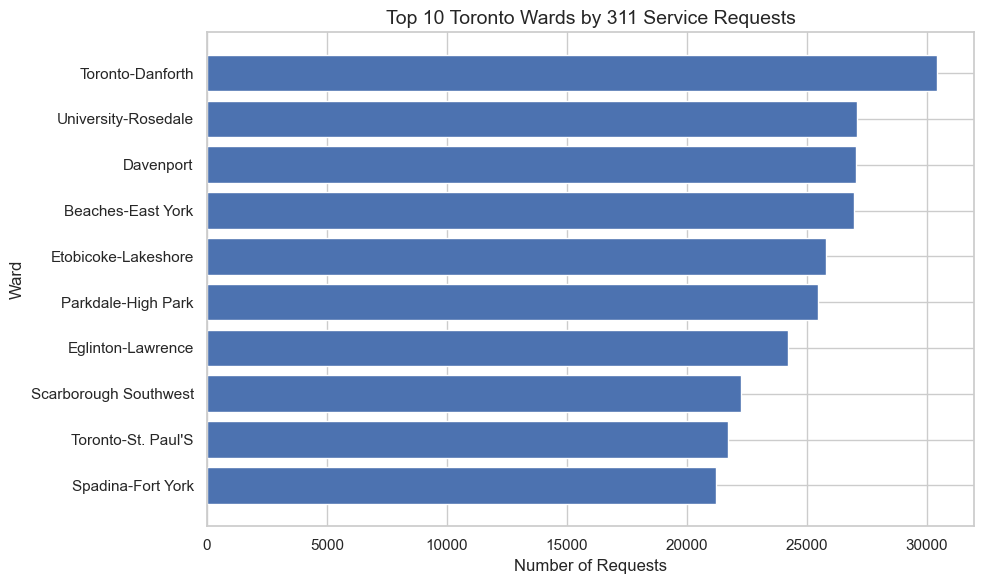

In [91]:
# Identify the 10 wards with the most requests
top_wards = ward_requests.head(10)

# Plot the highest-volume wards
plt.figure(figsize=(10, 6))
plt.barh(top_wards.index, top_wards.values)

plt.title("Top 10 Toronto Wards by 311 Service Requests")
plt.xlabel("Number of Requests")
plt.ylabel("Ward")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Key insight:** Toronto-Danforth recorded the highest overall 311 request volume with 30,448 requests, followed by University-Rosedale with 27,081 and Davenport with 27,073.

Request volume differs considerably across wards, although total counts should not automatically be interpreted as differences in service quality. Population, density, land use, infrastructure, and residents' use of the 311 system could all influence the number of requests submitted in each ward.

In [96]:
# Filter requests from the highest-volume ward
selected_ward = "Toronto-Danforth"

ward_data = df[df["ward_name"] == selected_ward]

# Identify the most common request types in the ward
ward_top_requests = (
    ward_data["service_request_type"]
    .value_counts()
    .head(10)
)

ward_top_requests

service_request_type
Property Standards And Maintenance Violations    1012
Pick Up Dead Wildlife                            1004
Residential Bin Lid Damaged                       882
General Pruning                                   870
Res / Recycle / Not Picked Up                     859
Res / Garbage / Not Picked Up                     795
Sidewalk Snow Clearing Required                   760
Injured - Wildlife                                676
Residential Bin Body Or Handle Damaged            638
Road Pothole / Road Damage                        622
Name: count, dtype: int64

**What Is Driving Demand in Toronto-Danforth?**

Since Toronto-Danforth recorded the highest overall request volume, I examined its most common service request types to determine which issues contribute most to demand in the ward.

**Key insight:** Toronto-Danforth does not appear to be dominated by a single type of service request. Property Standards and Maintenance Violations and Pick up Dead Wildlife were tied as the most common categories, with 1,012 and 1,004 requests respectively.

Waste collection, pruning, sidewalk snow clearing, wildlife, and pothole-related issues also appeared among the ward's most frequent requests, suggesting that its high overall volume comes from demand across several municipal services.

#### Potholes by Ward

In [94]:
# Identify wards with the most pothole and road damage requests
potholes_by_ward = (
    pothole_data["ward_name"]
    .value_counts()
    .head(10)
)

potholes_by_ward

ward_name
Etobicoke-Lakeshore    755
Toronto-St. Paul'S     751
Eglinton-Lawrence      671
Toronto-Danforth       622
Don Valley West        538
Scarborough Centre     509
Etobicoke North        499
Beaches-East York      492
York Centre            491
Spadina-Fort York      482
Name: count, dtype: int64

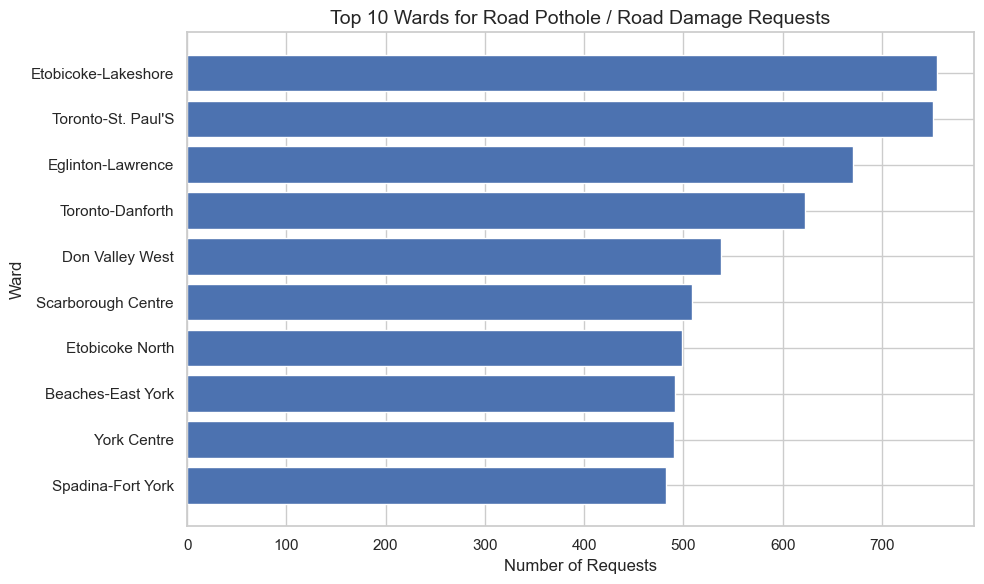

In [95]:
# Plot wards with the most pothole and road damage requests
plt.figure(figsize=(10, 6))
plt.barh(potholes_by_ward.index, potholes_by_ward.values)

plt.title("Top 10 Wards for Road Pothole / Road Damage Requests")
plt.xlabel("Number of Requests")
plt.ylabel("Ward")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Key insight:** Etobicoke-Lakeshore recorded the most Road Pothole / Road Damage requests with 755, closely followed by Toronto-St. Paul's with 751. Eglinton-Lawrence ranked third with 671 requests.

Interestingly, Toronto-Danforth had the highest total number of 311 requests overall but ranked fourth for pothole and road damage requests. This reinforces the importance of examining individual service categories rather than assuming that wards with the highest total demand also lead every type of request.

## Key Findings

The exploratory analysis identified several patterns in Toronto's 2025 311 service request data:

* **Service demand is concentrated in several major categories.** Residential Bin Lid Damaged was the most common individual request type, while Solid Waste Management Services handled the largest overall volume of requests.

* **Demand changes considerably throughout the year.** February recorded the highest overall request volume and was heavily influenced by snow-clearing and winter maintenance issues, while summer demand shifted toward pruning, wildlife, waste, and property-related concerns.

* **311 activity follows a clear weekly and daily pattern.** Requests were highest during the workweek, particularly on Wednesday, and peaked around 10:00–11:00 AM.

* **Road damage displays a strong seasonal pattern.** Pothole and road damage requests peaked sharply in March before declining through the remainder of the year.

* **Demand varies across Toronto wards.** Toronto-Danforth recorded the highest total request volume, but Etobicoke-Lakeshore recorded the most pothole and road damage requests, showing that different areas face different service pressures.

These findings provide the basis for the operational recommendations presented in the next section.